In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report, accuracy_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.naive_bayes import GaussianNB

import scipy.stats as stats

import warnings
warnings.filterwarnings('ignore')

In [3]:
# ==========================

# DATA SPLITTING & VALIDATION

# ==========================

from sklearn.model_selection import (
train_test_split,
# Use: Divide data into training and testing sets


cross_val_score,      
# Use: Check model performance multiple times

GridSearchCV,         
# Use: Find best parameters by testing all combinations

RandomizedSearchCV    
# Use: Find best parameters faster using random search


)

# ==========================

# DATA PREPROCESSING

# ==========================

from sklearn.preprocessing import (


OneHotEncoder,        
# Use: Convert text categories into columns
# Example: Red → [1,0,0]

LabelEncoder,         
# Use: Convert labels into numbers
# Example: Yes=1 No=0

OrdinalEncoder,       
# Use: Convert ordered categories into numbers
# Example: Small=1 Medium=2 Large=3

StandardScaler,       
# Use: Make data mean=0 and std=1
# Best for SVM, Logistic Regression

MinMaxScaler          
# Use: Scale values between 0 and 1


)

# ==========================

# DECISION TREE

# ==========================

from sklearn.tree import (


DecisionTreeClassifier,
# Use: Predict categories
# Example: Pass/Fail

DecisionTreeRegressor
# Use: Predict numbers
# Example: House Price


)

# ==========================

# MODEL EVALUATION

# ==========================

from sklearn.metrics import (


confusion_matrix,
# Use: Show correct and wrong predictions

precision_score,
# Use: Out of predicted positives, how many correct

recall_score,
# Use: Out of actual positives, how many found

f1_score,
# Use: Balance precision and recall

classification_report,
# Use: Print all classification metrics

accuracy_score,
# Use: Percentage of correct predictions

r2_score,
# Use: Regression model quality

mean_absolute_error,
# Use: Average prediction error

mean_squared_error
# Use: Penalize larger errors


)

# ==========================

# RANDOM FOREST

# ==========================

from sklearn.ensemble import (


RandomForestClassifier,
# Use: Classification using many trees

RandomForestRegressor
# Use: Regression using many trees


)

# ==========================

# LINEAR MODELS

# ==========================

from sklearn.linear_model import (


LinearRegression,
# Use: Predict continuous values

LogisticRegression,
# Use: Binary classification

Ridge,
# Use: Reduce overfitting (L2)

Lasso
# Use: Feature selection (L1)


)

# ==========================

# OTHER MODELS

# ==========================

from sklearn.svm import SVC

# Use: Classification with decision boundaries

from sklearn.neighbors import KNeighborsClassifier

# Use: Predict using nearest neighbors

# ==========================

# CLUSTERING

# ==========================

from sklearn.cluster import (


KMeans,
# Use: Group similar data

AgglomerativeClustering
# Use: Hierarchical clustering


)

# ==========================

# DIMENSION REDUCTION

# ==========================

from sklearn.decomposition import PCA

# Use: Reduce number of features

# ==========================

# PIPELINES

# ==========================

from sklearn.pipeline import Pipeline

# Use: Run preprocessing + model together

from sklearn.compose import ColumnTransformer

# Use: Apply different transforms to columns

# ==========================

# MISSING VALUES

# ==========================

from sklearn.experimental import enable_iterative_imputer

# Use: Enable IterativeImputer

from sklearn.impute import (


SimpleImputer,
# Use: Fill missing values

IterativeImputer
# Use: Predict missing values

)

# ==========================

# NAIVE BAYES

# ==========================

from sklearn.naive_bayes import GaussianNB

# Use: Fast probabilistic classifier

# ==========================

# STATISTICS

# ==========================

import scipy.stats as stats

# Use: Statistical testing

# ==========================

# WARNINGS

# ==========================

import warnings

warnings.filterwarnings('ignore')

# Use: Hide warning messages


In [2]:
from sklearn import datasets

In [3]:
from sklearn.datasets import load_iris

In [4]:
iris = load_iris()

In [5]:
df = pd.DataFrame(
    iris.data,
    columns = iris.feature_names
)

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3
149,5.9,3.0,5.1,1.8


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [10]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [11]:
df.sample()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
92,5.8,2.6,4.0,1.2


In [12]:
df.sample(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
65,6.7,3.1,4.4,1.4
84,5.4,3.0,4.5,1.5
114,5.8,2.8,5.1,2.4


In [13]:
df[['petal length (cm)']]
# Use: Select only one column as a DataFrame
# Output: Shows all rows of "petal length (cm)"
# Double [[]] returns DataFrame

,petal length (cm)
0,1.4
1,1.4
2,1.3
3,1.5
4,1.4
...,...
145,5.2
146,5.0
147,5.2
148,5.4


In [14]:
df.isnull()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
145,False,False,False,False
146,False,False,False,False
147,False,False,False,False
148,False,False,False,False


In [15]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [16]:
df.isnull().sum().sum()

np.int64(0)

In [17]:
df.notnull().sum()

sepal length (cm)    150
sepal width (cm)     150
petal length (cm)    150
petal width (cm)     150
dtype: int64

In [18]:
df.shape    # rows, columns

(150, 4)

In [19]:
df.shape[0]  # rows

150

In [20]:
df.shape[1]  # columns

4

In [21]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object

In [22]:
df[['petal length (cm)']].dtypes

petal length (cm)    float64
dtype: object

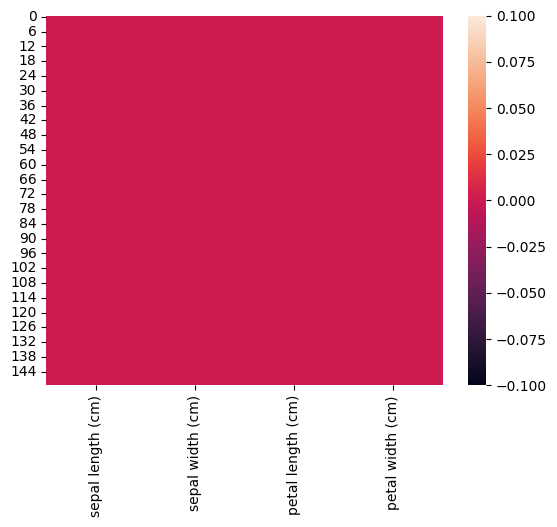

In [7]:
sns.heatmap(df.isnull())

# Use: Visualize missing (null) values in dataset
# Same color everywhere → No missing values
# Different colored spots → Missing values exist
# True = Missing value
# False = Value available

plt.show()

In [8]:
df.drop(df.columns[0], axis=1)

,sepal width (cm),petal length (cm),petal width (cm)
0,3.5,1.4,0.2
1,3.0,1.4,0.2
2,3.2,1.3,0.2
3,3.1,1.5,0.2
4,3.6,1.4,0.2
...,...,...,...
145,3.0,5.2,2.3
146,2.5,5.0,1.9
147,3.0,5.2,2.0
148,3.4,5.4,2.3


In [9]:
df.dropna()

# Use: Remove rows having missing (NaN) values
# If NO missing values in dataset:
# → Nothing will be removed
# → Same DataFrame will be returned
# (no change in rows or columns)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [10]:
df.fillna(10).head()

# Use: Fill all missing (NaN) values with 10
# If no missing values:
# → Data will remain same (no change)
# .head() shows first 5 rows only

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [11]:
df['petal width (cm)'].mode()

0    0.2
Name: petal width (cm), dtype: float64

In [12]:
mode_val = df['sepal length (cm)'].mode()
if not mode_val.empty:
    df['sepal length (cm)'] = df['sepal length (cm)'].fillna(mode_val.iloc[0])
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [13]:
df.select_dtypes(include='object')

""
0
1
2
3
4
...
145
146
147
148


In [14]:
df.select_dtypes(include='float')

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [15]:
from sklearn.impute import SimpleImputer
si = SimpleImputer()

In [16]:
a = si.fit_transform(df[['petal length (cm)', 'petal width (cm)']])

# OneHotEncoding

In [17]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

In [19]:
from sklearn import datasets
from sklearn.datasets import load_wine

wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [23]:
en_data = df[['alcohol', 'malic_acid']]

In [24]:
pd.get_dummies(en_data)

,alcohol,malic_acid
0,14.23,1.71
1,13.20,1.78
2,13.16,2.36
3,14.37,1.95
4,13.24,2.59
...,...,...
173,13.71,5.65
174,13.40,3.91
175,13.27,4.28
176,13.17,2.59


In [25]:
ohe.fit_transform(en_data)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 356 stored elements and shape (178, 259)>

In [26]:
ohe.fit_transform(en_data).toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(178, 259))

# LabelEncoder

In [29]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [30]:
le.fit_transform(df['alcohol'])

array([118,  65,  63, 121,  67, 115, 123, 109, 125, 103, 110, 111,  96,
       124, 122,  87, 119, 101, 114,  88, 109,  55,  92,  51,  81,  59,
        75,  71, 104, 108,  94,  85,  90,  97,  82,  79,  69,  59,  60,
       117,  84,  77, 105,  67,  59, 116, 122, 106, 110, 107,  59, 101,
       100,  98,  95,  84, 117,  70,  93,  31,  28,  41,  89,  31,  22,
        31,  62,  31,  73,  24,  27, 103,  80,  57,  16,   9,  58,  14,
        28,  44,  17,  45,  20,  59,  14,  42,  21,   8,   7,  20,  20,
        17,  43,  27,   6,  35,  12,  27,  31,  27,  20,  40,  29,  13,
        36,  32,  26,  45,  25,   5,   3,  37,  10,   1,  20,   0,  13,
        32,  46,  17,   2,   4,  32,  59,  15,  19,  33,  11,  31,  18,
        52,  54,  48,  44,  36,  40,  26,  38,  80,  50,  55,  74,  83,
        86,  26,  63, 105,  53,  72,  61,  81,  47,  62,  66,  39,  64,
       102,  34, 120,  79,  30,  91,  51,  56,  99,  94,  78,  49,  85,
        76,  23,  46, 113,  92,  76,  68,  64, 112])

In [31]:
le.fit(df['alcohol'])

LabelEncoder()

In [32]:
le.transform(df['alcohol'])

array([118,  65,  63, 121,  67, 115, 123, 109, 125, 103, 110, 111,  96,
       124, 122,  87, 119, 101, 114,  88, 109,  55,  92,  51,  81,  59,
        75,  71, 104, 108,  94,  85,  90,  97,  82,  79,  69,  59,  60,
       117,  84,  77, 105,  67,  59, 116, 122, 106, 110, 107,  59, 101,
       100,  98,  95,  84, 117,  70,  93,  31,  28,  41,  89,  31,  22,
        31,  62,  31,  73,  24,  27, 103,  80,  57,  16,   9,  58,  14,
        28,  44,  17,  45,  20,  59,  14,  42,  21,   8,   7,  20,  20,
        17,  43,  27,   6,  35,  12,  27,  31,  27,  20,  40,  29,  13,
        36,  32,  26,  45,  25,   5,   3,  37,  10,   1,  20,   0,  13,
        32,  46,  17,   2,   4,  32,  59,  15,  19,  33,  11,  31,  18,
        52,  54,  48,  44,  36,  40,  26,  38,  80,  50,  55,  74,  83,
        86,  26,  63, 105,  53,  72,  61,  81,  47,  62,  66,  39,  64,
       102,  34, 120,  79,  30,  91,  51,  56,  99,  94,  78,  49,  85,
        76,  23,  46, 113,  92,  76,  68,  64, 112])

In [33]:
total_phenols = df['total_phenols'].unique()

In [34]:
total_phenols

array([2.8 , 2.65, 3.85, 3.27, 2.5 , 2.6 , 2.98, 2.95, 2.2 , 3.1 , 3.3 ,
       2.85, 2.7 , 3.  , 2.41, 2.61, 2.48, 2.53, 2.63, 2.4 , 2.86, 2.42,
       2.35, 2.45, 3.15, 3.25, 2.64, 2.75, 2.88, 2.72, 3.88, 2.96, 3.2 ,
       3.4 , 1.98, 2.05, 2.02, 2.1 , 3.5 , 1.89, 2.11, 1.85, 1.1 , 1.88,
       3.38, 1.61, 1.95, 1.72, 1.9 , 2.83, 2.  , 1.65, 1.78, 1.92, 1.6 ,
       1.45, 1.38, 3.02, 2.55, 3.52, 2.23, 2.56, 1.68, 2.36, 2.74, 3.18,
       1.75, 2.46, 1.63, 2.9 , 2.62, 2.13, 2.22, 1.51, 1.3 , 1.15, 1.7 ,
       1.62, 1.79, 2.32, 1.54, 1.4 , 1.55, 1.5 , 0.98, 1.93, 1.41, 1.48,
       1.8 , 1.74, 2.3 , 1.83, 1.39, 1.35, 1.28, 1.25, 1.59])

# OrdinalEncoder

In [38]:
df = pd.DataFrame({
    'size': ['Small', 'Medium', 'Large', 'Medium', 'Small', 'Large'],
    'color': ['Red', 'Green', 'Blue', 'Green', 'Red', 'Blue']
})

In [39]:
df.head()

,size,color
0,Small,Red
1,Medium,Green
2,Large,Blue
3,Medium,Green
4,Small,Red


In [41]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder()

In [44]:
oe.fit(df[['size']])

,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [46]:
oe.transform(df[['size']])

array([[2.],
       [1.],
       [0.],
       [1.],
       [2.],
       [0.]])